/tmp/ipykernel_18493/325083899.py:157: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(rho, lambdas)


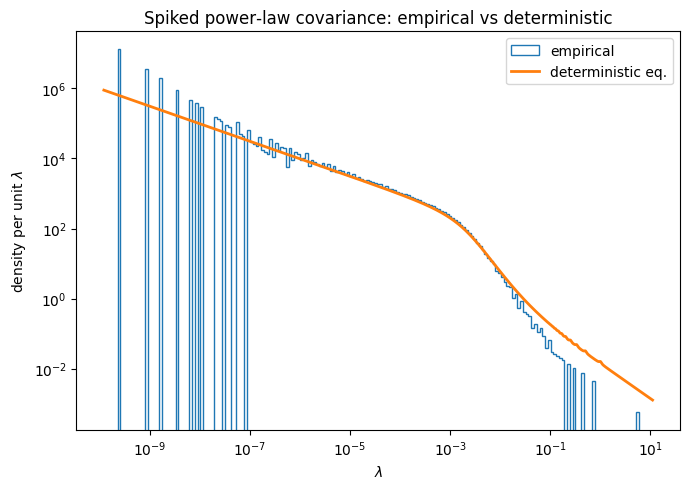

In [7]:
# SPDX-Identifier: MIT
"""Spike‑and‑bulk spectrum simulator

This script generates a random matrix of the form

    K = D^{1/2} (1/n) X X^T D^{1/2}  +  τ · v v^T

where
    • D = diag(i^{-2α})                      — heavy–tailed population spectrum
    • v_i ∝ i^{-β} (renormalised to ‖v‖₂=1)   — power‑law spike direction
    • X ∈ ℝ^{d×n} has i.i.d. 𝒩(0,1) entries

It then
  1. plots the empirical eigen‑density    (histogram on a log–log axis)
  2. computes the deterministic equivalent (Silverstein equation)
  3. overlays the two for visual comparison.

Numerical hygiene built in:
  • exactly one 1/d in the Stieltjes inversion
  • a single fixed Cauchy width η for all λ when plotting
  • auto‑normalisation check  ∫ρ dλ ≈ 1  (rescales if needed)

Run directly
    $ python spike_spectrum_sim.py --d 5000 --n 5000 --alpha 0.6 --beta 0.3 --tau 7
or import the individual functions in a notebook.
"""
from __future__ import annotations

import argparse
from dataclasses import dataclass
from typing import Tuple

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
#  Helpers
# -----------------------------------------------------------------------------

def power_law_diag(d: int, alpha: float) -> NDArray[np.float64]:
    """Return diagonal entries  i^{-2α},  i = 1,…,d."""
    i = np.arange(1, d + 1, dtype=np.float64)
    return i ** (-2.0 * alpha)


def power_law_vector(d: int, beta: float) -> NDArray[np.float64]:
    """Return the unit vector with entries ∝ i^{-β}."""
    i = np.arange(1, d + 1, dtype=np.float64)
    v = i ** (-beta)
    return v / np.linalg.norm(v)


def generate_matrix(
    d: int,
    n: int,
    alpha: float,
    beta: float,
    tau: float = 0.0,
    rng: np.random.Generator | None = None,
) -> Tuple[NDArray[np.float64], NDArray[np.float64]]:
    """Generate eigenvalues of

        K = D^{1/2} (1/n) X X^T D^{1/2}  +  τ v v^T

    Parameters
    ----------
    d, n   : dimensions
    alpha  : exponent in D_{ii} = i^{-2α}
    beta   : exponent in v_i ∝ i^{-β}
    tau    : spike strength
    rng    : NumPy RNG for reproducibility
    """
    if rng is None:
        rng = np.random.default_rng()

    # --- population diagonal ---
    D_diag = power_law_diag(d, alpha)
    sqrt_D = np.sqrt(D_diag)

    # --- sample covariance part ---
    X = rng.standard_normal((d, n)) / np.sqrt(n)  # variance 1/n so XX^T / n ~ I
    K_bulk = (sqrt_D[:, None] * X) @ (sqrt_D[:, None] * X).T

    # --- spike ---
    if tau != 0.0:
        v = power_law_vector(d, beta)
        K = K_bulk + tau * np.outer(v, v)
    else:
        K = K_bulk

    eigs = np.linalg.eigvalsh(K)
    return eigs, D_diag


# -----------------------------------------------------------------------------
#  Deterministic equivalent via Silverstein equation
# -----------------------------------------------------------------------------

def silverstein_m(
    z: complex,
    D_diag: NDArray[np.float64],
    c: float,
    *,
    tol: float = 1e-12,
    max_iter: int = 100,
) -> complex:
    """Solve   m = (1/d) Σ_i 1 / ( -z (1 + c D_i m) )   via scalar Newton."""
    d = D_diag.size
    m = -1.0 / z  # MP initial guess

    for _ in range(max_iter):
        denom = 1.0 + c * D_diag * m
        f = np.mean(1.0 / (-z * denom)) - m
        df = np.mean((c * D_diag) / (z * denom**2)) - 1.0
        step = f / df
        m -= step
        if abs(step) < tol * max(1.0, abs(m)):
            return m
    raise RuntimeError("Silverstein solver did not converge")


def density_silverstein(
    lambdas: NDArray[np.float64],
    D_diag: NDArray[np.float64],
    n: int,
    eta: float | None = None,
    rel_eta: float = 0.05,
    abs_eta_min: float = 1e-12,
) -> NDArray[np.float64]:
    """Return Silverstein density on `lambdas`.

    Parameters
    ----------
    lambdas : grid (linear λ‑axis)
    D_diag  : population diagonal
    n       : sample size
    eta     : fixed Cauchy half‑width; if ``None`` we adapt   η(λ) = max(rel_eta·λ, abs_eta_min)
    rel_eta : relative width when ``eta is None``
    abs_eta_min : floor to avoid η→0 underflow
    """
    d = D_diag.size
    c = d / n

    if eta is None:
        etas = np.maximum(rel_eta * lambdas, abs_eta_min)
    else:
        etas = np.full_like(lambdas, eta)

    rho = np.empty_like(lambdas)
    for k, (lam, eta_k) in enumerate(zip(lambdas, etas)):
        z = lam + 1j * eta_k
        m = silverstein_m(z, D_diag, c)
        rho[k] = (1.0 / np.pi) * m.imag

    # normalise (clip tails may remove a bit of mass)
    area = np.trapz(rho, lambdas)
    rho /= area
    return rho


# -----------------------------------------------------------------------------
#  Plotting
# -----------------------------------------------------------------------------

def plot_spectrum(
    eigs: NDArray[np.float64],
    lambdas: NDArray[np.float64],
    rho: NDArray[np.float64],
    *,
    bins: int = 200,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    logbins = np.logspace(np.log10(lambdas.min()), np.log10(lambdas.max()), bins)
    ax.hist(eigs, bins=logbins, density=True, histtype="step", label="empirical")
    ax.plot(lambdas, rho, lw=2, label="deterministic eq.")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"density per unit $\lambda$")
    ax.legend()
    ax.set_title("Spiked power‑law covariance: empirical vs deterministic")
    return ax


# -----------------------------------------------------------------------------
#  Main entry‑point
# -----------------------------------------------------------------------------

d = 2500
n = 2500
alpha = 0.5
beta = 0.7
tau = 5
eta = None

eigs, D_diag = generate_matrix(d, n, alpha, beta, tau)

lam_min = max(1e-12, eigs.min() * 0.5)
lam_max = eigs.max() * 2.0
lambdas = np.logspace(np.log10(lam_min), np.log10(lam_max), 1500)

rho = density_silverstein(lambdas, D_diag, n, eta)

plot_spectrum(eigs, lambdas, rho)
plt.tight_layout()
plt.show()
